# Explore data store

- import packages

In [1]:
from pathlib import Path
from RES import utility as utils
import matplotlib.pyplot as plt

import RES.visuals as vis
from RES.hdf5_handler import DataHandler

plt.style.use('../RES/visual_styles/elsevier.mplstyle')

## Define Province specific attributes 
> for locating data and plot styling

In [2]:
province_code:str='BC' # The tool is designed to work for any province of CANADA.
scenario=1.2
legend_x_ax_offset=0.92
legend_y_ax_offset=0.82

In [3]:
from pathlib import Path

# Define the directory and search pattern
data_store_dir = Path("../data/store/")
search_keyword = f"resources_{province_code}_"

# List files containing the search pattern
matching_files = [str(f) for f in data_store_dir.glob(f"*{search_keyword}*") if f.is_file()]

# Extract run IDs from matching_files
run_ids = [f.replace(str(data_store_dir) + '/', '').replace(search_keyword, '').replace(".h5", '') for f in matching_files]

##  Define run/scenario

In [4]:
import ipywidgets as widgets
from IPython.display import display

RUN_ID="default"

# Create dropdown widget
run_id_dropdown = widgets.Dropdown(
    options=run_ids,
    value=RUN_ID,
    description='Run ID:',
    disabled=False,
)

display(run_id_dropdown)

Dropdown(description='Run ID:', options=('default', 'policy_aeroway_CPCAD_buffer', 'old'), value='default')

## Load Store

In [5]:
store=f"../data/store/resources_{province_code}_{RUN_ID}.h5"# f"../data/store/resources_{province_code}.h5" 
res_data=DataHandler(store,show_structure=True) # the DataHandler object could be initiated without the store definition as well.

____________________________________________________________
     RES.hdf5_handler|🗄️ Structure of HDF5 file: ../data/store/resources_BC_default.h5
____________________________________________________________
[key] boundary
[key] cells
[key] clusters
  └─ [key] clusters/solar
  └─ [key] clusters/wind
[key] cost
  └─ [key] cost/atb
  └─   └─ [key] cost/atb/solar
  └─   └─ [key] cost/atb/wind
[key] dissolved_indices
  └─ [key] dissolved_indices/solar
  └─ [key] dissolved_indices/wind
[key] substations
[key] timeseries
  └─ [key] timeseries/clusters
  └─   └─ [key] timeseries/clusters/solar
  └─   └─ [key] timeseries/clusters/wind
  └─ [key] timeseries/solar
  └─ [key] timeseries/wind
[key] units


└> To access the data : 
 └> <datahandler instance>.from_store('<key>')


* Load Data from Store

In [6]:
# Loading Grid Cells Geodataframe
cells=res_data.from_store('cells')
boundary=res_data.from_store('boundary')
solar_clusters=res_data.from_store('clusters/solar')
wind_clusters=res_data.from_store('clusters/wind')
units=res_data.from_store('units')
lines=res_data.from_store('lines')
substations=res_data.from_store('substations')

  └> RES.hdf5_handler| ❌ Error: Key 'lines' not found in ../data/store/resources_BC_default.h5


In [7]:
# vis.get_selected_vs_missed_visuals(cells,'BC','solar',10,0.15,100)

In [8]:
# vis.get_selected_vs_missed_visuals(cells,'BC','wind',10,0.15,100)

In [9]:
# cells[cells['potential_capacity_solar']==0].explore()

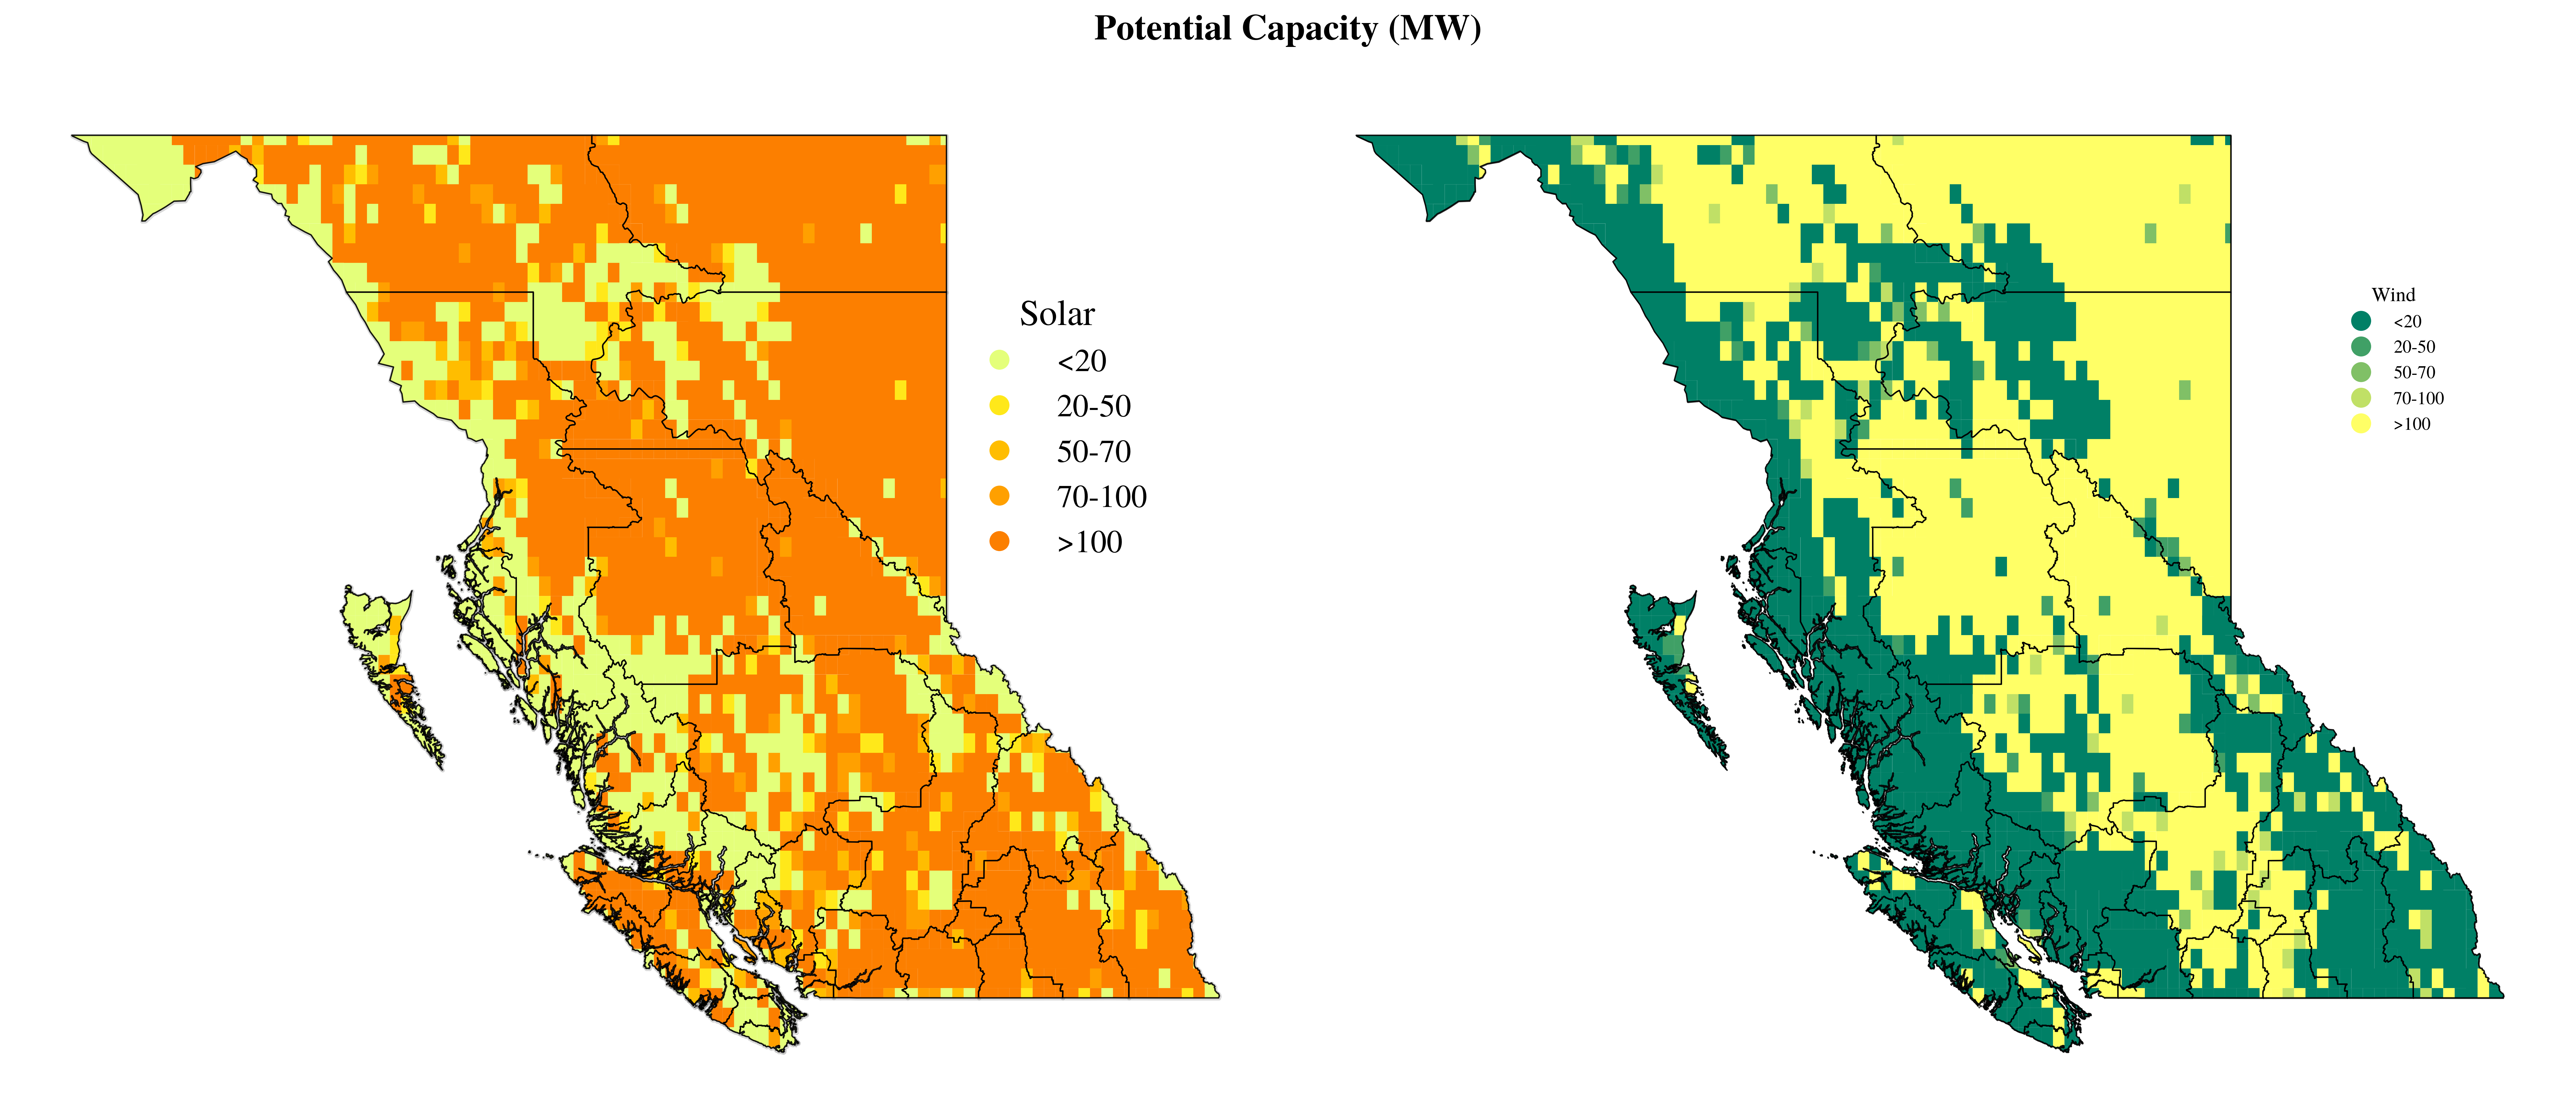

In [10]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'Region' is in the columns for both boundary and cells
if 'Region' not in boundary.columns:
    boundary = boundary.reset_index(inplace=True)

# Assign a number to each region
boundary['Region_Number'] = range(1, len(boundary) + 1)

# Define custom bins and labels for solar and wind capacity
bins = [0, 20, 50, 70, 100, float('inf')]  # Custom ranges
labels = ['<20','20-50', '50-70', '70-100', '>100']  # Labels for legend

# Categorize potential_capacity_solar and potential_capacity_wind into bins
cells['solar_category'] = pd.cut(cells['potential_capacity_solar'], bins=bins, labels=labels, include_lowest=True)
cells['wind_category'] = pd.cut(cells['potential_capacity_wind'], bins=bins, labels=labels, include_lowest=True)

# Create figure and axes for side-by-side plotting
fig, (ax1, ax2) = plt.subplots(figsize=(18, 8), ncols=2)
fig.suptitle("Potential Capacity (MW)", fontsize=18, fontweight='bold')
ax1.set_axis_off()
ax2.set_axis_off()

# Shadow effect offset
shadow_offset = 0.008

# Plot solar map on ax1
boundary.geometry = boundary.geometry.translate(xoff=shadow_offset, yoff=-shadow_offset)
boundary.plot(ax=ax1, facecolor='none', edgecolor='gray', linewidth=2, alpha=0.3)
boundary.geometry = boundary.geometry.translate(xoff=-shadow_offset, yoff=shadow_offset)

# Plot solar cells
solar_plot = cells.plot(
    column='solar_category', ax=ax1, cmap='Wistia', legend=True,
    legend_kwds={
        'title': "Solar", 
        'loc': 'upper right',
        'bbox_to_anchor': (legend_x_ax_offset, legend_y_ax_offset),
        'fontsize': 16,
        'frameon': False,
        'title_fontsize': 18
    }
)

boundary.plot(ax=ax1, facecolor='none', edgecolor='black', linewidth=0.7, alpha=0.9)

# Plot wind map on ax2
boundary.geometry = boundary.geometry.translate(xoff=shadow_offset, yoff=-shadow_offset)
boundary.plot(ax=ax2, color='None', edgecolor='k', linewidth=0.5, alpha=0.7)
boundary.geometry = boundary.geometry.translate(xoff=-shadow_offset, yoff=shadow_offset)

wind_plot = cells.plot(
    column='wind_category', ax=ax2, cmap='summer', legend=True,
    legend_kwds={
        'title': "Wind",
        'bbox_to_anchor': (legend_x_ax_offset, legend_y_ax_offset),
    #     'fontsize': 14,
    #     'frameon': False,
    #     'title_fontsize': 18
    }
)

boundary.plot(ax=ax2, facecolor='none', edgecolor='black', linewidth=0.7, alpha=0.9)


plt.tight_layout()
plt.show()


In [11]:
# from RES import visuals as vis

# vis.plot_grid_lines(province_code, 
#                     'BC',
#                     lines,
#                     boundary=boundary,
#                     save_to='../vis/' + province_code + '/misc')

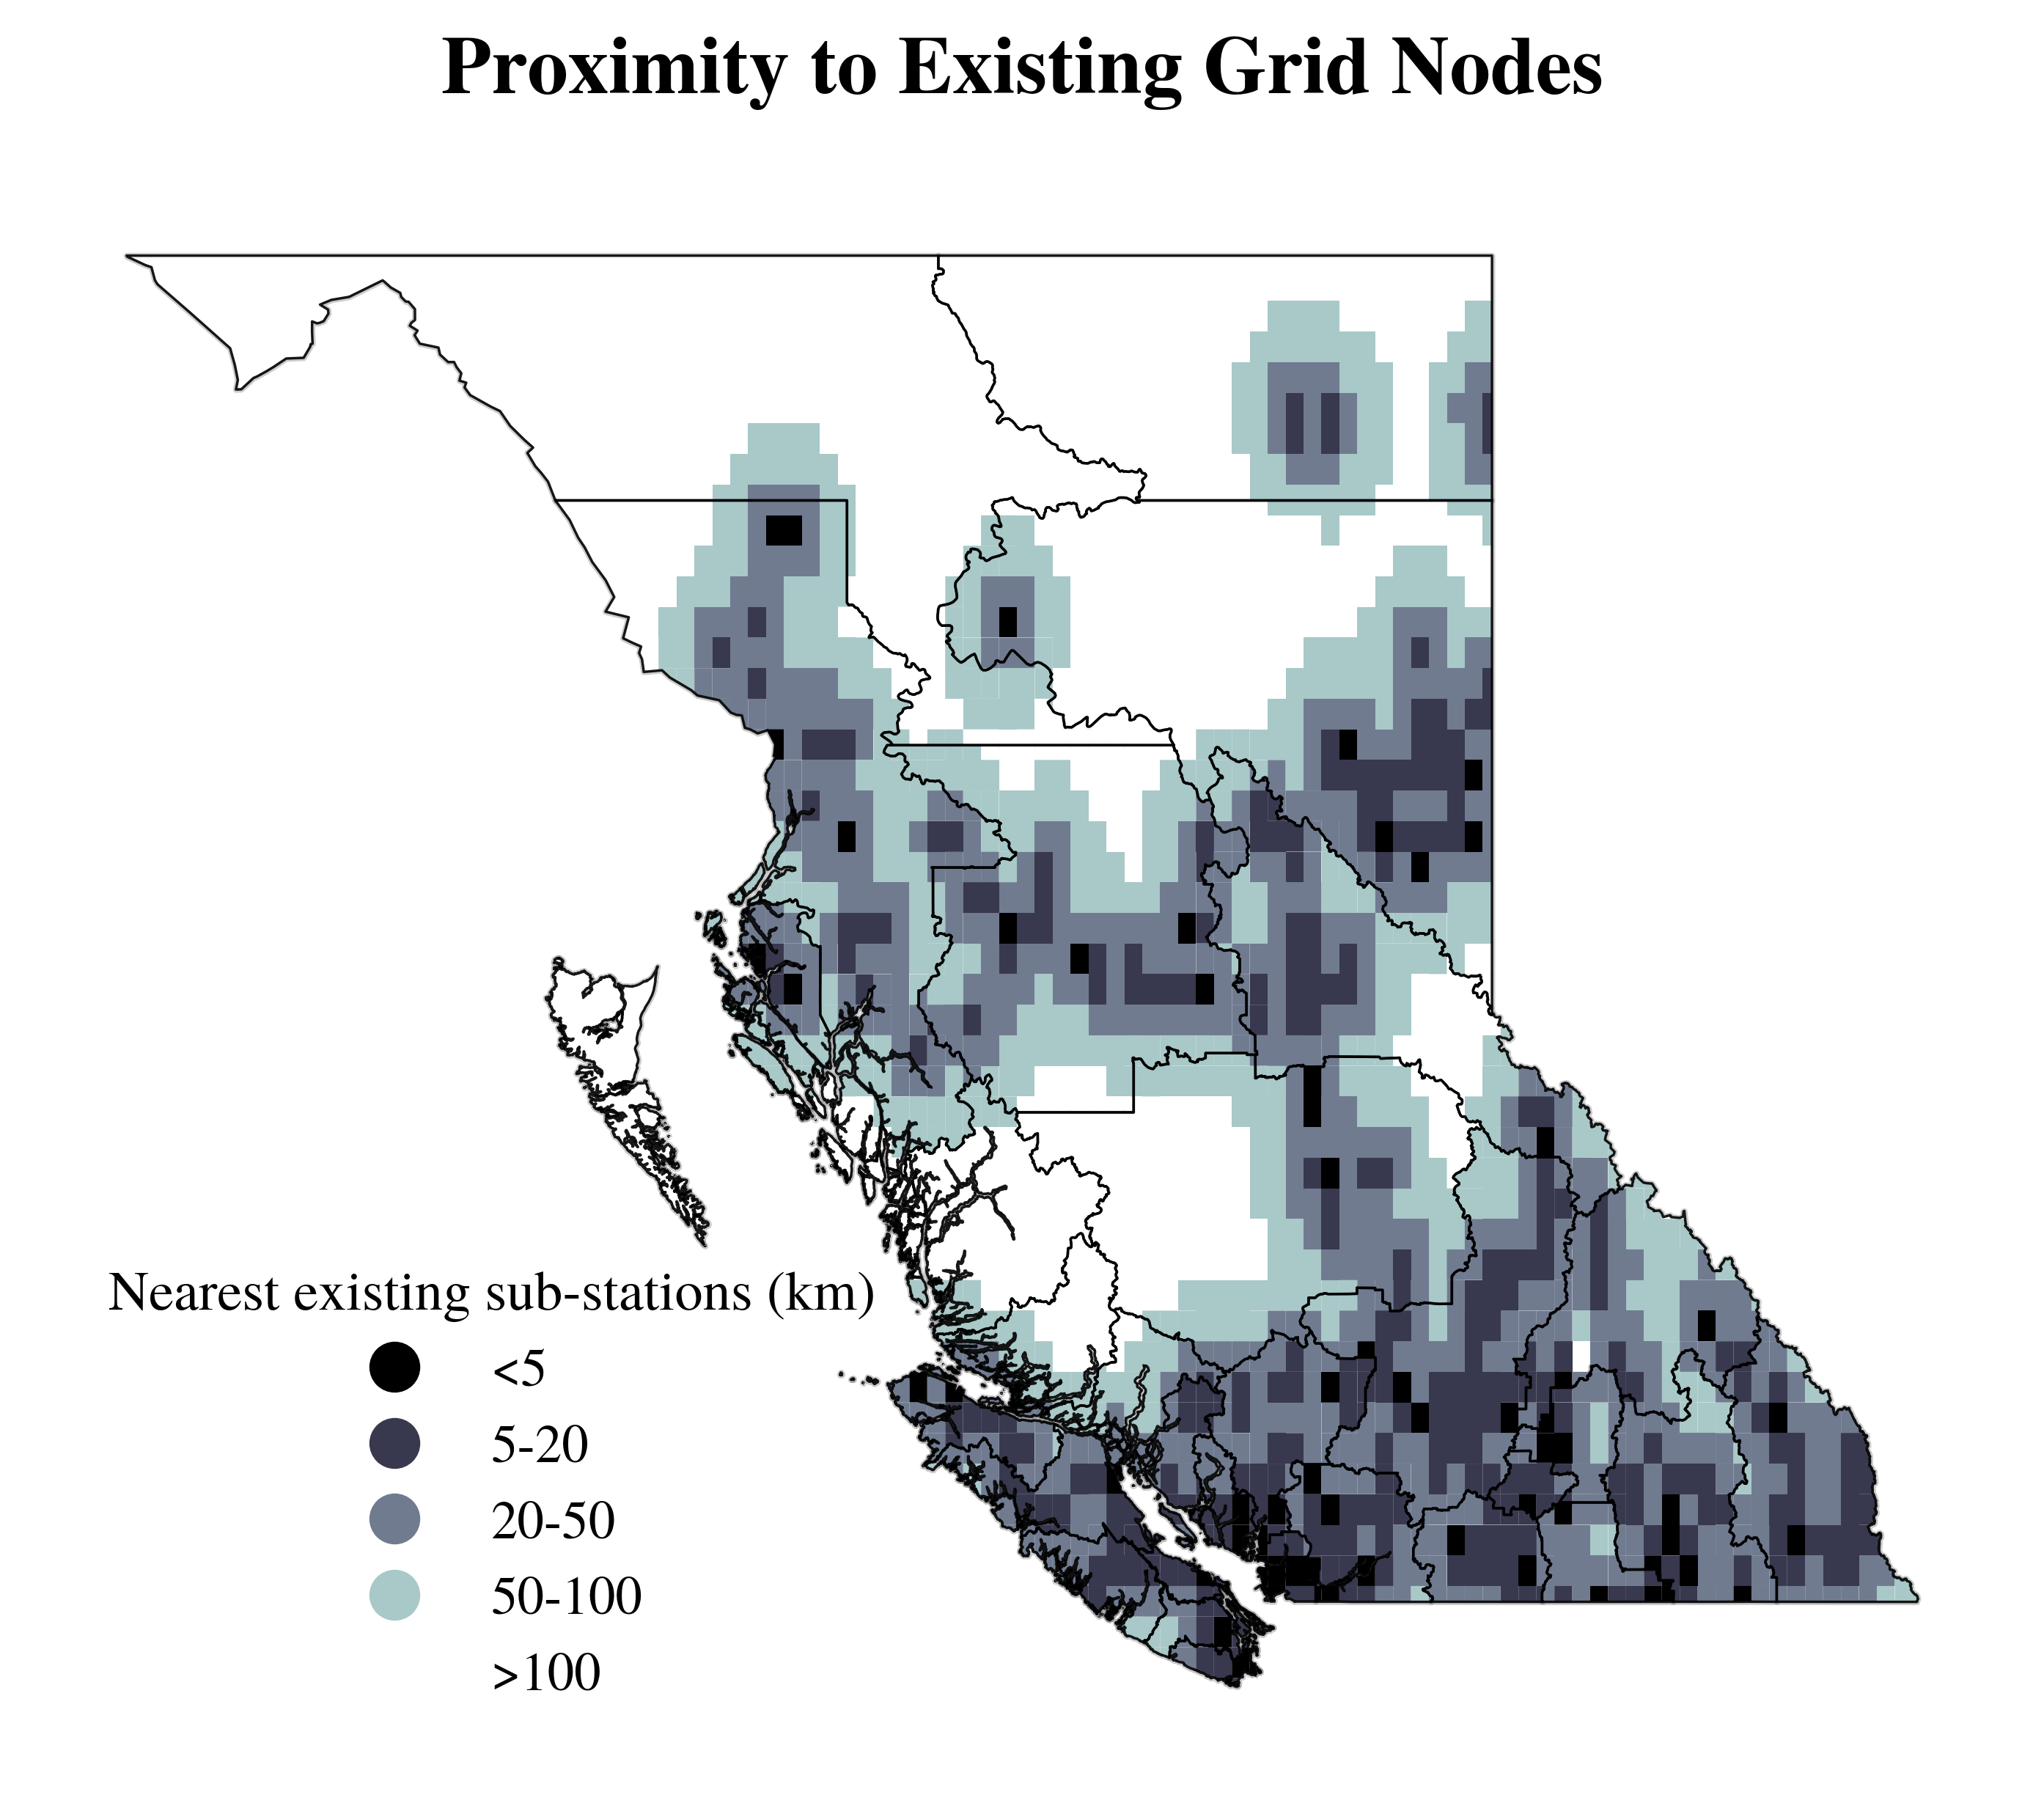

In [41]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'Region' is in the columns for both boundary and cells
if 'Region' not in boundary.columns:
    boundary = boundary.reset_index(inplace=True)


# Define custom bins and labels for solar and wind capacity
bins = [0, 5, 20, 50, 100, float('inf')]  # Custom ranges
labels = ['<5','5-20', '20-50', '50-100', '>100']  # Labels for legend

# Categorize potential_capacity_solar and potential_capacity_wind into bins
cells['station_distance_category'] = pd.cut(cells['nearest_station_distance_km'], bins=bins, labels=labels, include_lowest=True)


# Create figure and axes for side-by-side plotting
fig, (ax) = plt.subplots(figsize=(7, 5),dpi=500)
fig.suptitle("Proximity to Existing Grid Nodes", fontsize=16, fontweight='bold')
ax.set_axis_off()

# Shadow effect offset
shadow_offset = 0.002

# Plot solar map on ax1
# Add shadow effect for solar map
boundary.geometry = boundary.geometry.translate(xoff=shadow_offset, yoff=-shadow_offset)
boundary.plot(ax=ax, facecolor='none', edgecolor='gray', linewidth=1.2, alpha=0.4)  # Shadow layer
boundary.geometry = boundary.geometry.translate(xoff=-shadow_offset, yoff=shadow_offset)

# Plot solar cells
cells.plot(
    column='station_distance_category',
    ax=ax,
    cmap='bone',
    legend=True,
    legend_kwds={
        'title': "Nearest existing sub-stations (km)",
        'title_fontsize': 11,
        'loc': 'upper right',
        'bbox_to_anchor': (0.45, 0.34),
        'fontsize':10.5,
        'frameon': False
    }
)

# Plot actual boundary for solar map
boundary.plot(ax=ax, facecolor='None', edgecolor='black', linewidth=0.5, alpha=0.9)

# Adjust layout for cleaner appearance
# fig.patch.set_alpha(0)  # Make figure background transparent
plt.tight_layout()
save_to = Path(f"../vis/{province_code}/misc/Resources_proximity_to_grid_{province_code}.jpg")
save_to.parent.mkdir(parents=True, exist_ok=True)  # Ensure the directory exists
plt.savefig(save_to, bbox_inches='tight')
plt.savefig(f"../docs/source/_static/Resources_proximity_to_grid_{province_code}.jpg", dpi=300, bbox_inches='tight')

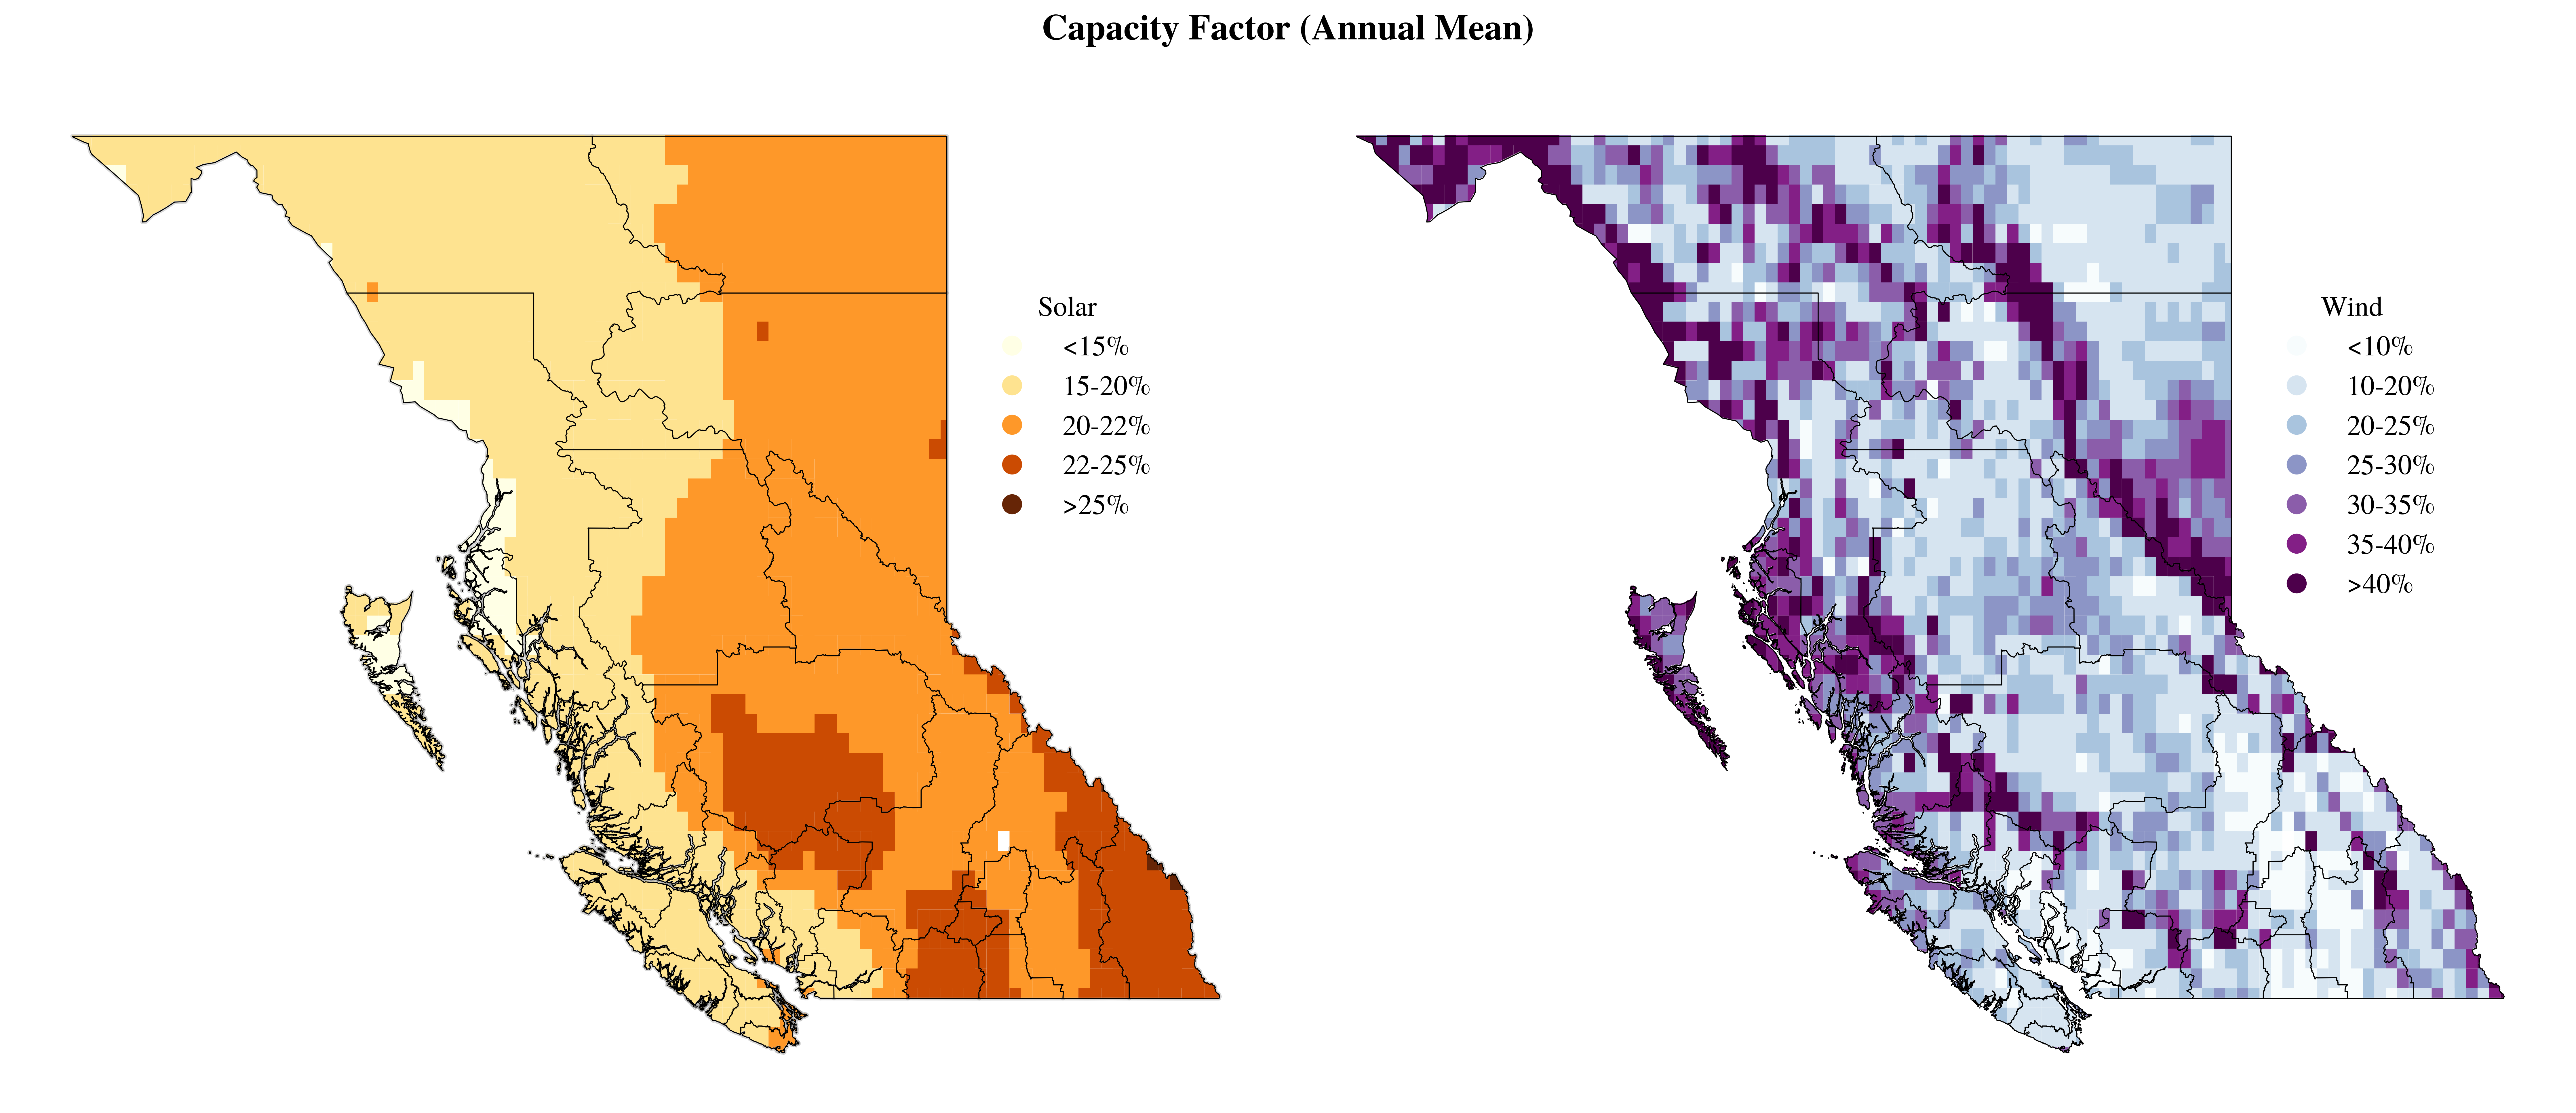

In [43]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'Region' is in the columns for both boundary and cells
if 'Region' not in boundary.columns:
    boundary = boundary.reset_index(inplace=True)

# Assign a number to each region
boundary['Region_Number'] = range(1, len(boundary) + 1)

# Define custom bins and labels for solar and wind capacity
solar_bins = [0, 0.15, 0.20, 0.22, 0.25, float('inf')]  # Custom ranges
solar_labels = ['<15%', '15-20%', '20-22%', '22-25%', '>25%']  # Labels for legend

# Define custom bins and labels for solar and wind capacity
wind_bins = [0, .10, .20, .25,.30, .35, .40, float('inf')]  # Custom ranges
wind_labels = ['<10%','10-20%', '20-25%','25-30%','30-35%','35-40%','>40%']  # Labels for legend

# Drop rows where solar_CF_mean or wind_CF_mean is zero
cells = cells[(cells['solar_CF_mean'] > 0) & (cells['wind_CF_mean'] > 0)]

# Categorize potential_capacity_solar and potential_capacity_wind into bins
cells['solar_category'] = pd.cut(cells['solar_CF_mean'], bins=solar_bins, labels=solar_labels, include_lowest=True)
cells['wind_category'] = pd.cut(cells['wind_CF_mean'], bins=wind_bins, labels=wind_labels, include_lowest=True)

# Create figure and axes for side-by-side plotting
fig, (ax1, ax2) = plt.subplots(figsize=(18, 8), ncols=2)
fig.suptitle("Capacity Factor (Annual Mean)", fontsize=18, fontweight='bold')
# Set axis off for both subplots
ax1.set_axis_off()
ax2.set_axis_off()

# Shadow effect offset
shadow_offset = 0.0001

# Plot solar map on ax1
# Add shadow effect for solar map
boundary.geometry = boundary.geometry.translate(xoff=shadow_offset, yoff=-shadow_offset)
boundary.plot(ax=ax1, facecolor='none', edgecolor='gray', linewidth=2, alpha=0.3)  # Shadow layer
boundary.geometry = boundary.geometry.translate(xoff=-shadow_offset, yoff=shadow_offset)

# Plot solar cells
cells.plot(column='solar_category', ax=ax1, cmap='YlOrBr', legend=True, 
        legend_kwds={'title': "Solar", 'title_fontsize': 14, 'bbox_to_anchor': (legend_x_ax_offset, legend_y_ax_offset), 'fontsize': 14, 'frameon': False})

# Plot actual boundary for solar map
boundary.plot(ax=ax1, facecolor='none', edgecolor='k', linewidth=0.5, alpha=1)

""" 
# Annotate region numbers for solar map
for idx, row in boundary.iterrows():
    centroid = row.geometry.centroid
    ax1.annotate(f"{row['Region_Number']}", 
                 xy=(centroid.x, centroid.y), 
                 ha='center', va='center',
                 fontsize=7, color='black',
                 bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, boxstyle='round,pad=0.2'))
"""
# Plot wind map on ax2
# Add shadow effect for wind map
# boundary.geometry = boundary.geometry.translate(xoff=shadow_offset, yoff=-shadow_offset)
boundary.plot(ax=ax2, color='None', edgecolor='k', linewidth=0.5, alpha=0.7)  # Shadow layer
boundary.geometry = boundary.geometry.translate(xoff=-shadow_offset, yoff=shadow_offset)

# Plot wind cells
cells.plot(column='wind_category', ax=ax2, cmap='BuPu', legend=True, 
           legend_kwds={'title': "Wind", 'title_fontsize':14, 'bbox_to_anchor':(legend_x_ax_offset,legend_y_ax_offset),'fontsize':14,'frameon': False})

# Plot actual boundary for wind map
boundary.plot(ax=ax2, facecolor='none', edgecolor='k', linewidth=0.5, alpha=1)
"""
# Annotate region numbers for wind map
for idx, row in boundary.iterrows():
    centroid = row.geometry.centroid
    ax2.annotate(f"{row['Region_Number']}", 
                 xy=(centroid.x, centroid.y), 
                 ha='center', va='center',
                 fontsize=8, color='black',
                 bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, boxstyle='round,pad=0.2'))
"""
# Adjust layout for cleaner appearance
fig.patch.set_alpha(0)  # Make figure background transparent

plt.tight_layout()

# Show the side-by-side plot

# plt.savefig('solar_wind_CF_map.png',dpi=300)
plt.show()

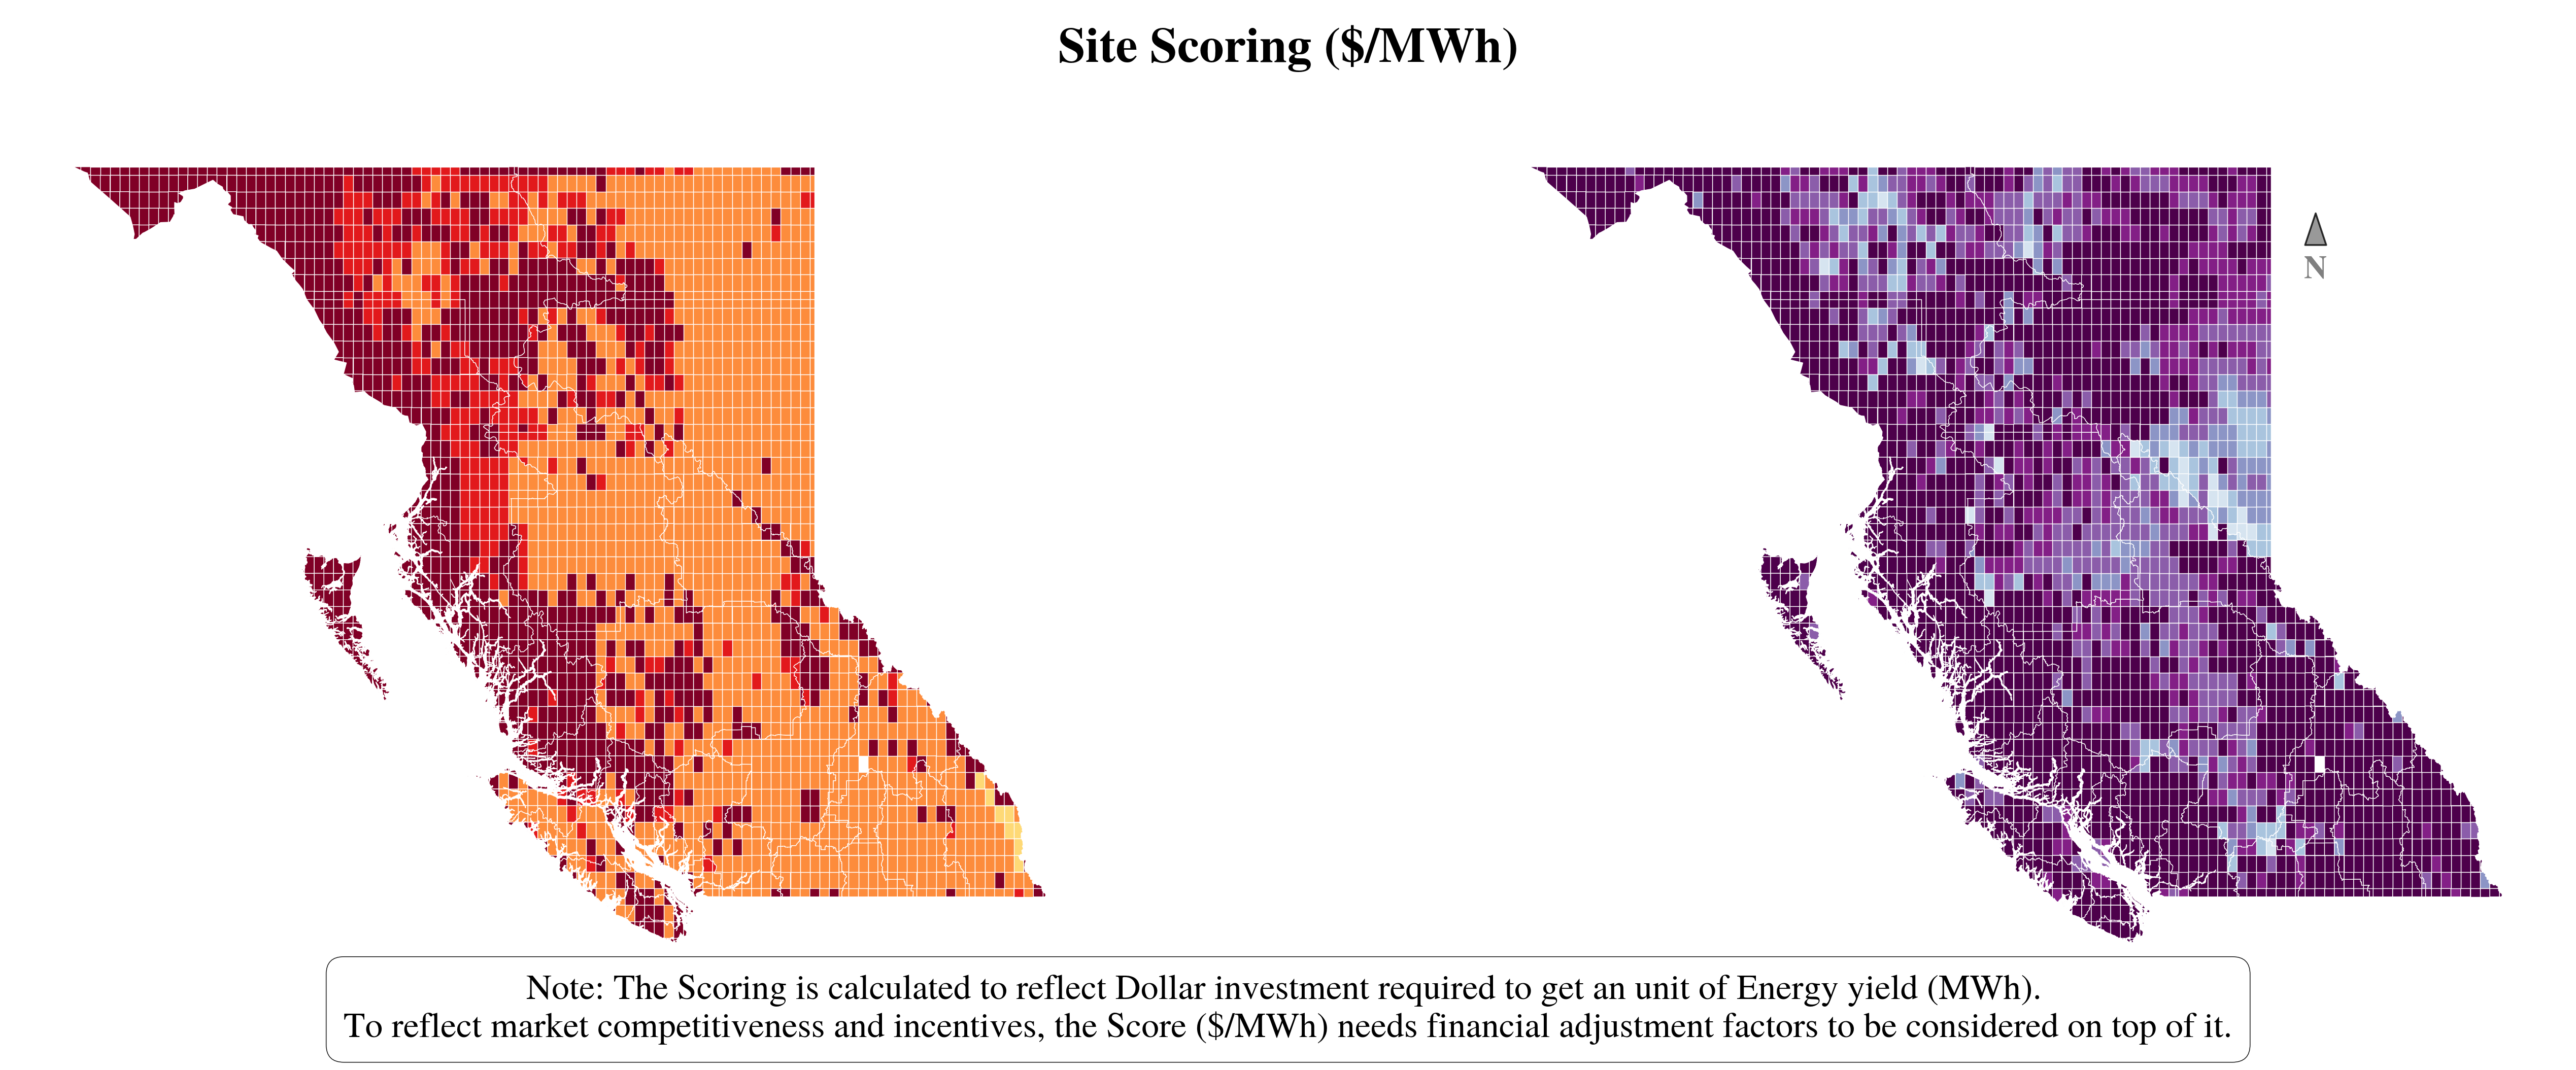

In [78]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'Region' is in the columns for both boundary and cells
# if 'Region' not in boundary.columns:
#     boundary = boundary.reset_index(inplace=True)

# # Assign a number to each region
# boundary['Region_Number'] = range(1, len(boundary) + 1)

# Define custom bins and labels for solar and wind capacity
solar_bins = [20, 30, 50, 70, 80, float('inf')]  # Custom ranges
solar_labels = ['<20','20-30', '30-55','50-70','>80']  # Labels for legend

# Define custom bins and labels for solar and wind capacity
wind_bins = [20, 30, 40, 50, 60, 80, 100, float('inf')]  # Custom ranges
wind_labels = ['<20','20-30', '30-40','40-50','50-60', '60-80', '>100']  # Labels for legend

# Categorize potential_capacity_solar and potential_capacity_wind into bins
cells['solar_category'] = pd.cut(cells['lcoe_solar'], bins=solar_bins, labels=solar_labels, include_lowest=True)
cells['wind_category'] = pd.cut(cells['lcoe_wind'], bins=wind_bins, labels=wind_labels, include_lowest=True)

# Create figure and axes for side-by-side plotting
fig, (ax1, ax2) = plt.subplots(figsize=(12, 4), ncols=2,dpi=500)
fig.suptitle("Site Scoring ($/MWh)", fontsize=14, fontweight='bold')
# Set axis off for both subplots
ax1.set_axis_off()
ax2.set_axis_off()

# Shadow effect offset
# shadow_offset = 0.001

# Plot solar map on ax1
# Add shadow effect for solar map
# boundary.geometry = boundary.geometry.translate(xoff=shadow_offset, yoff=-shadow_offset)
# boundary.plot(ax=ax1, facecolor='none', edgecolor='gray', linewidth=1.2, alpha=0.3)  # Shadow layer
# boundary.geometry = boundary.geometry.translate(xoff=-shadow_offset, yoff=shadow_offset)

# Plot solar cells
cells.plot(column='solar_category', ax=ax1, cmap='YlOrRd', legend=False, edgecolor='white',linewidth=0.2,alpha=1,
        #    legend_kwds={'title': "Solar",'title_fontsize':14, 'bbox_to_anchor':(legend_x_ax_offset,legend_y_ax_offset),'fontsize':14,'frameon': False}
           )

# # Plot actual boundary for solar map
# boundary.plot(ax=ax1, facecolor='none', edgecolor='black', linewidth=0.2, alpha=0.9)

""" 
# Annotate region numbers for solar map
for idx, row in boundary.iterrows():
    centroid = row.geometry.centroid
    ax1.annotate(f"{row['Region_Number']}", 
                 xy=(centroid.x, centroid.y), 
                 ha='center', va='center',
                 fontsize=7, color='black',
                 bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, boxstyle='round,pad=0.2'))
"""
# Plot wind map on ax2
# Add shadow effect for wind map
# boundary.geometry = boundary.geometry.translate(xoff=shadow_offset, yoff=-shadow_offset)
# boundary.plot(ax=ax2, color='None', edgecolor='k', linewidth=0.2, alpha=0.7)  # Shadow layer
# boundary.geometry = boundary.geometry.translate(xoff=-shadow_offset, yoff=shadow_offset)

# Plot wind cells
cells.plot(column='wind_category', ax=ax2, cmap='BuPu', legend=False, edgecolor='white',linewidth=0.2,alpha=1,
        #    legend_kwds={'title': "Wind", 'title_fontsize':14, 'bbox_to_anchor':(legend_x_ax_offset,legend_y_ax_offset),'fontsize':14,'frameon': False}
           )

# Plot actual boundary for wind map
# boundary.plot(ax=ax2, facecolor='none', edgecolor='black', linewidth=0.2, alpha=0.9)
"""
# Annotate region numbers for wind map
for idx, row in boundary.iterrows():
    centroid = row.geometry.centroid
    ax2.annotate(f"{row['Region_Number']}", 
                 xy=(centroid.x, centroid.y), 
                 ha='center', va='center',
                 fontsize=8, color='black',
                 bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, boxstyle='round,pad=0.2'))
"""
# Adjust layout for cleaner appearance
fig.patch.set_alpha(0)  # Make figure background transparent
# Add annotation to the figure
fig.text(0.5, 0.01, 
         "Note: The Scoring is calculated to reflect Dollar investment required to get an unit of Energy yield (MWh). "
         "\nTo reflect market competitiveness and incentives, the Score ($/MWh) needs financial adjustment factors to be considered on top of it.",
         ha='center', va='center', fontsize=10, color='k', bbox=dict(facecolor='None', edgecolor='k',linewidth=0.2,boxstyle='round,pad=0.5'))
plt.tight_layout()

# Show the side-by-side plot
# vis.add_compass_arrow_custom(ax1,text_offset=0.03)
vis.add_compass_arrow_custom(ax2,x=0.78,text_offset=0.04)
plt.savefig('../vis/BC/solar_wind_score_map.jpg')

/tmp/ipykernel_1008366/3237965040.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  solar_cmap = cm.get_cmap('YlOrRd', len(solar_labels))
/tmp/ipykernel_1008366/3237965040.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  wind_cmap = cm.get_cmap('BuPu', len(wind_labels))
/tmp/ipykernel_1008366/3237965040.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cells.groupby('solar_category')['potential_capacity_solar']
/tmp/ipykernel_1008366/323796

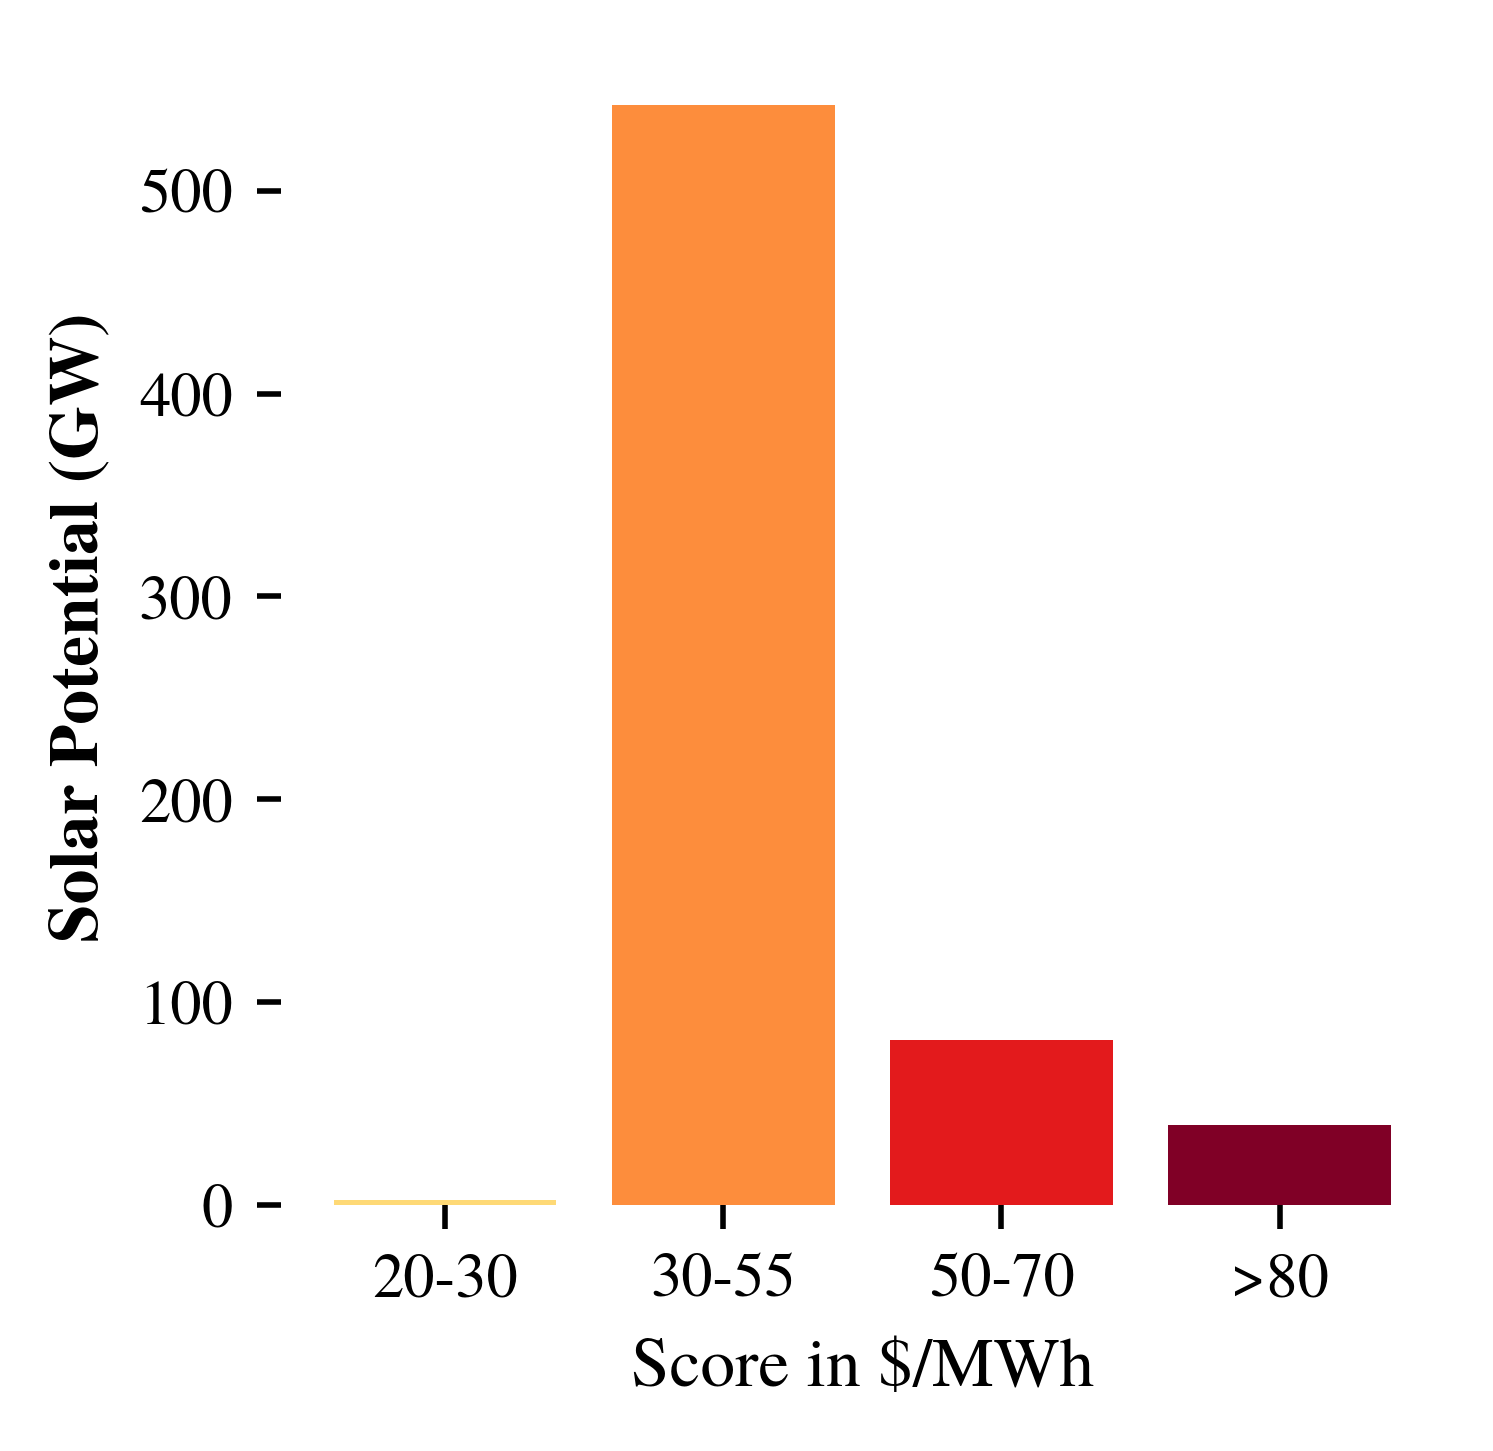

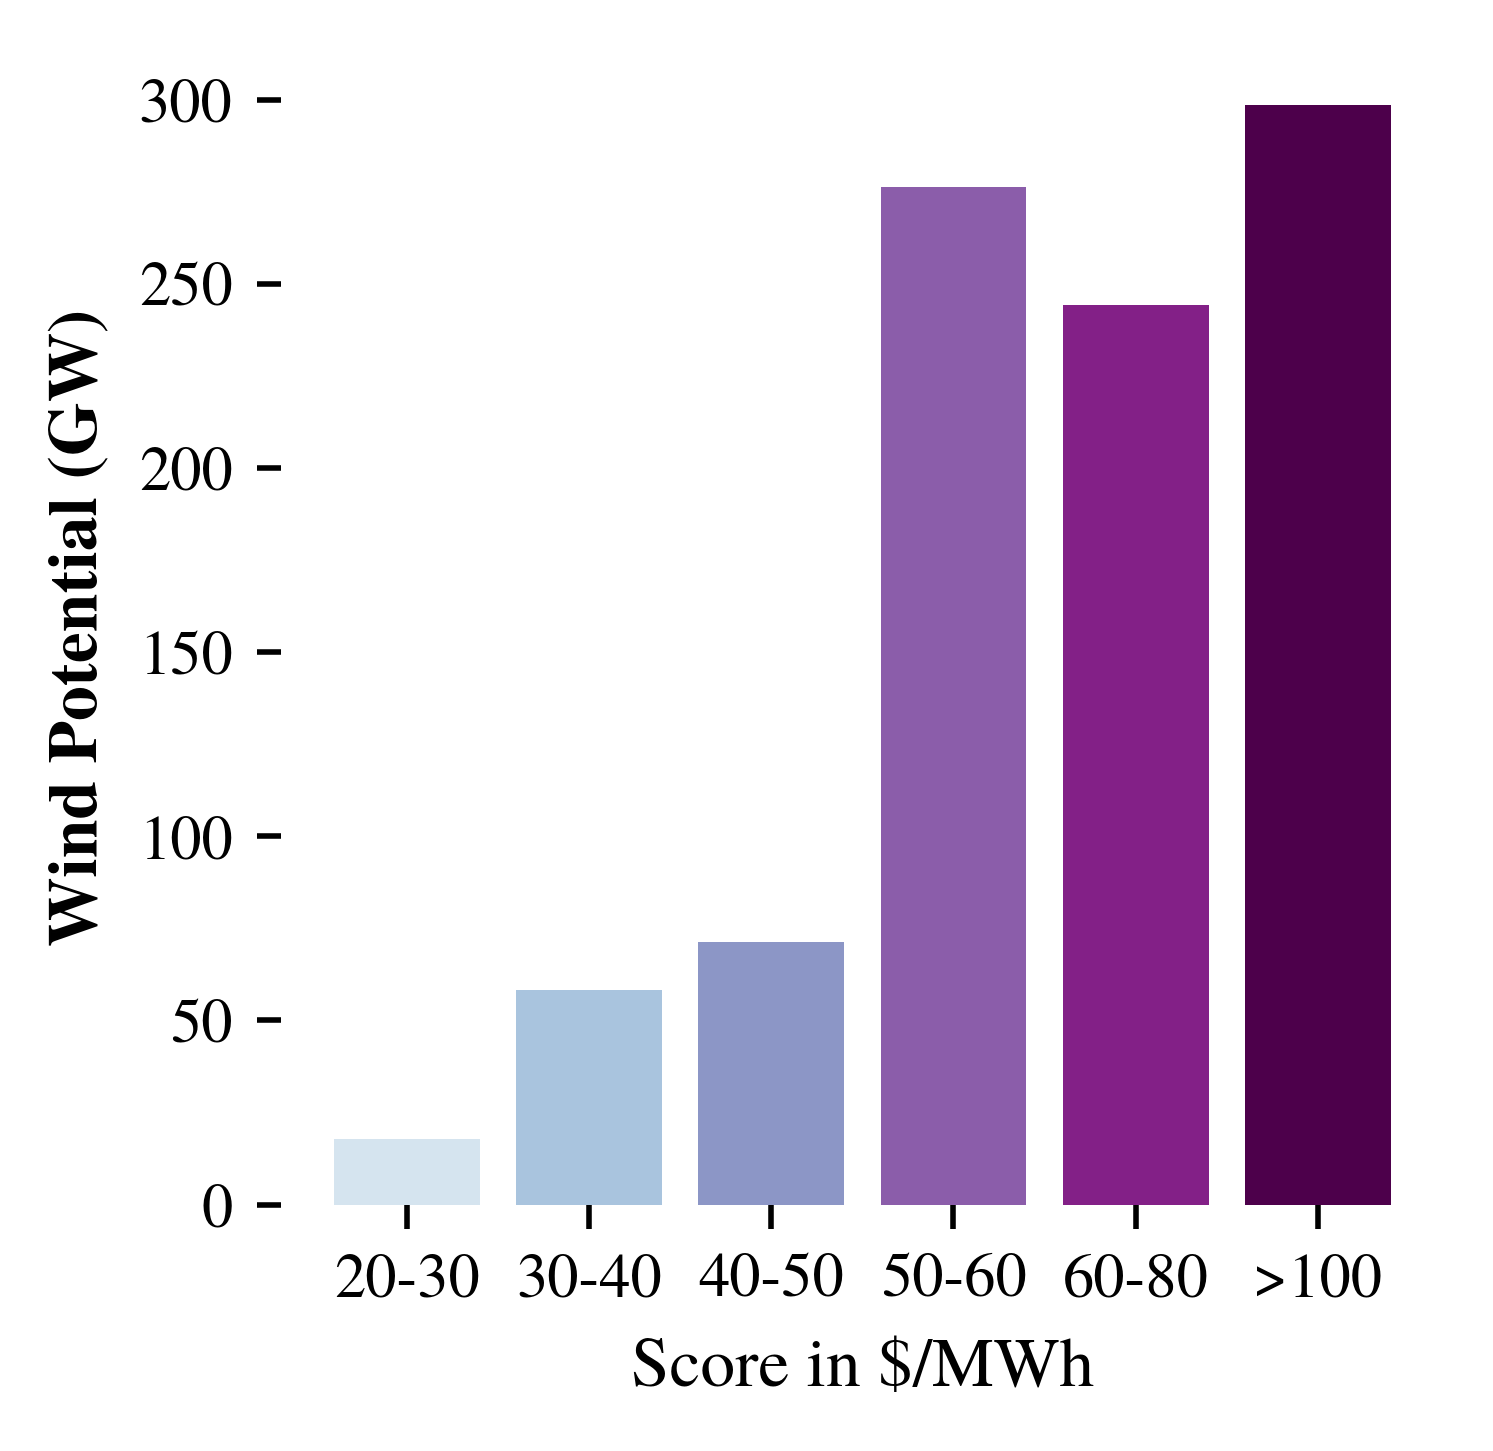

In [93]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# Define colormaps
solar_cmap = cm.get_cmap('YlOrRd', len(solar_labels))
wind_cmap = cm.get_cmap('BuPu', len(wind_labels))

# Generate colors for each bin
solar_colors = [mcolors.rgb2hex(solar_cmap(i)) for i in range(len(solar_labels))]
wind_colors = [mcolors.rgb2hex(wind_cmap(i)) for i in range(len(wind_labels))]

# Aggregate potential capacity for each bin
solar_capacity = (
    cells.groupby('solar_category')['potential_capacity_solar']
    .sum().div(1e3)
    .reindex(solar_labels, fill_value=0)
)
wind_capacity = (
    cells.groupby('wind_category')['potential_capacity_wind']
    .sum().div(1e3)
    .reindex(wind_labels, fill_value=0)
)

# --- Drop bins with 0 capacity ---
solar_capacity = solar_capacity[solar_capacity > 0]
wind_capacity = wind_capacity[wind_capacity > 0]

solar_colors_filtered = [solar_colors[solar_labels.index(lbl)] for lbl in solar_capacity.index]
wind_colors_filtered = [wind_colors[wind_labels.index(lbl)] for lbl in wind_capacity.index]

### Solar Plot ###
fig1, ax1 = plt.subplots(figsize=(3, 3), dpi=500)
fig1.patch.set_alpha(0)          # transparent figure background
ax1.set_facecolor('none')        # transparent axis background

ax1.bar(solar_capacity.index, solar_capacity.values, color=solar_colors_filtered, edgecolor='none')
ax1.set_ylabel('Solar Potential (GW)', fontsize=10, weight='bold')
ax1.set_xlabel('Score in $/MWh', fontsize=10)

# Clean look
for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.tick_params(bottom=True, left=True)

plt.savefig('../vis/BC/solar_wind_score_bar1.png', transparent=True)

### Wind Plot ###
fig2, ax2 = plt.subplots(figsize=(3, 3), dpi=500)
fig2.patch.set_alpha(0)
ax2.set_facecolor('none')

ax2.bar(wind_capacity.index, wind_capacity.values, color=wind_colors_filtered, edgecolor='none')
ax2.set_ylabel('Wind Potential (GW)', fontsize=10, weight='bold')
ax2.set_xlabel('Score in $/MWh', fontsize=10)

for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.tick_params(bottom=True, left=True)

plt.savefig('../vis/BC/solar_wind_score_bar2.png', transparent=True)
